In [1]:
import matplotlib.pyplot as plt
import json
import os
import seaborn as sns
import pandas as pd

Matplotlib is building the font cache; this may take a moment.


In [39]:
# OUTPUT_PATH = '/home/oluwatobi-alao/workspace/research/hiring-dss-research/data/simulation/output/final/workflow'
OUTPUT_PATH = '/Users/tobialao/workspace/research/hiring-dss-simulation/data/simulation/output'
EVAL_PATH = '/Users/tobialao/workspace/research/hiring-dss-simulation/data/simulation/evaluation'


In [40]:
test_cases = []

model_map = {
    '8b_Q4': 'workflow_8b_Q4',
    '8b_Q8': 'workflow_8b_Q8',
    '8b_QF16': 'workflow_8b',
    'openai': 'workflow_openai',
}


def extract_inference_time(data):
    result = {}
    for key in data:
        result[key] = [obj['processing_time'] for obj in data[key]]
    return result


def load_data(path: str):
    result = {}
    files = os.listdir(path)
    for file in files:
        if file.endswith('.json'):
            code = file.split('.')[0].split('_')[-1]
            with open(os.path.join(path, file), 'r') as f:
                result[code] = json.load(f)
    return result


def merge_objects(primary_list, secondary_list):
    """
    Merges two lists of dictionaries based on matching 'question_id' (from primary) and 'id' (from secondary).
    Returns a merged list of dictionaries.
    """
    # Build a mapping from id to secondary object
    secondary_map = {item.get('id'): item for item in secondary_list}

    merged = []

    for obj in primary_list:
        question_id = obj.get("question_id")

        # Try to find a matching secondary object
        secondary_obj = secondary_map.get(question_id)

        # If found, merge the dictionaries
        if secondary_obj:
            merged_obj = {
                **obj,  # Start with all fields from the primary object
                "context": obj.get("context")[0],
                "correct": secondary_obj.get("correct"),
                "answer_relevant": secondary_obj.get("answer_relevant"),
                "context_relevant": secondary_obj.get("context_relevant"),
                "relevancy_score": secondary_obj.get("relevancy_score"),
                "context_relevancy_score": secondary_obj.get("context_relevancy_score"),
                "relevancy_reason": secondary_obj.get("relevancy_reason"),
                "context_relevancy_reason": secondary_obj.get("context_relevancy_reason"),
                "path": secondary_obj.get("path") or obj.get("processing_path"),
                "path_len": (
                    secondary_obj.get("path_len")
                    if secondary_obj.get("path_len") is not None
                    else len(obj["processing_path"])
                ),
            }
            del merged_obj["processing_path"]
            del merged_obj["power_consumption"]
            del merged_obj["error"]
            merged.append(merged_obj)
        else:
            # If no match, you may choose to keep the original object or skip
            merged.append(obj)

    return merged

In [41]:
model_inference_data = {}
model_full_data = {}
for key in model_map:
    simulation_data = load_data(os.path.join(OUTPUT_PATH, model_map[key]))
    evaluation_data = load_data(os.path.join(EVAL_PATH, key))
    tc_merged = {}
    for tc in simulation_data:
        tc_merged[tc] = merge_objects(simulation_data[tc], evaluation_data[tc])
    model_full_data[key] = tc_merged
    model_inference_data[key] = extract_inference_time(simulation_data)


In [42]:
full_evaluation_data = model_full_data.copy()

In [43]:
for key in model_full_data:
    for tc in model_full_data[key]:
        for item in model_full_data[key][tc]:
            del item["expected_output"]
            del item["prompt"]
            del item["model_response"]
            del item["context"]
            del item["relevancy_reason"]
            del item["context_relevancy_reason"]

In [44]:
# with open('eval_output_combined.json', 'w') as f:
#     json.dump(model_full_data, f, indent=2)

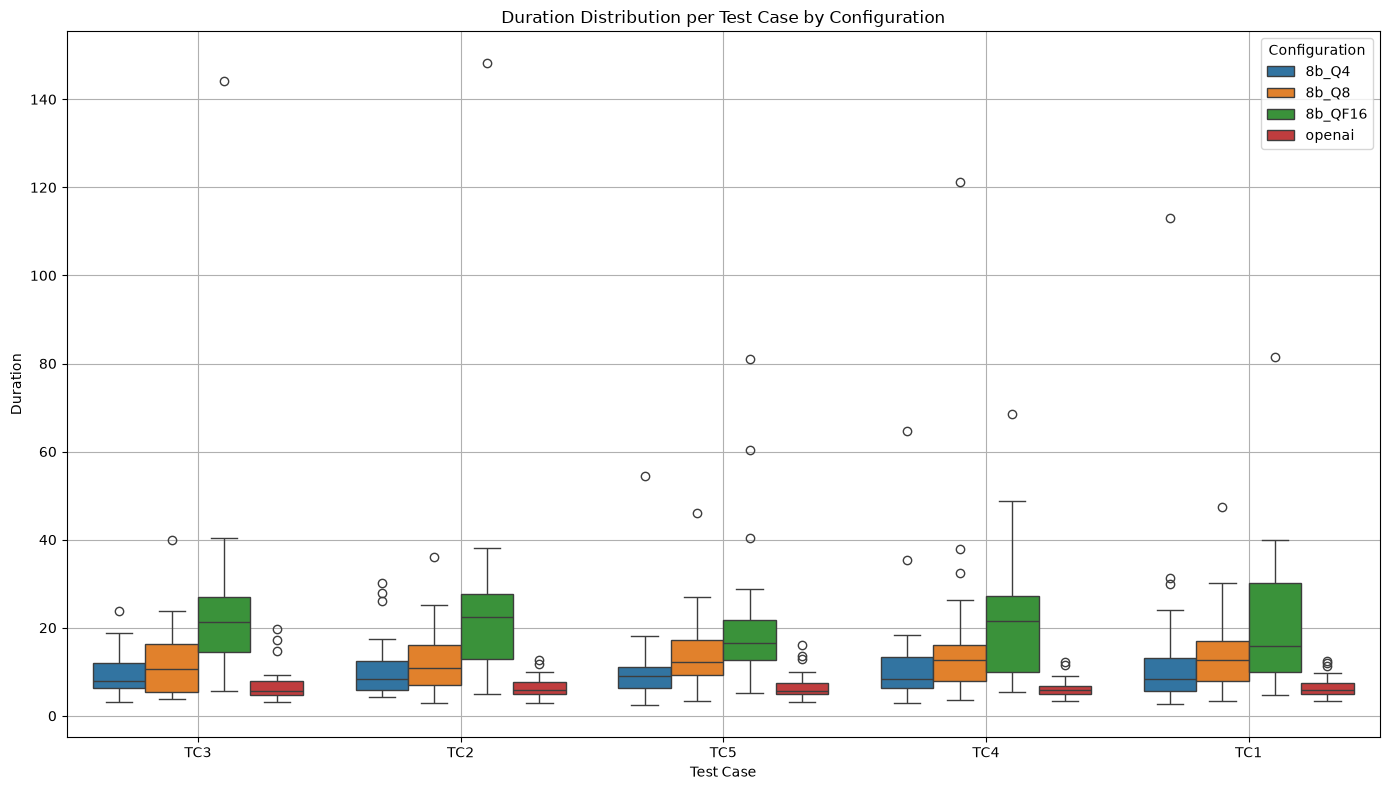

In [45]:
# Flatten data into a DataFrame suitable for box plots
rows = []
for config, tests in model_inference_data.items():
    for tc_name, values in tests.items():
        for value in values:
            rows.append({
                'Configuration': config,
                'Test Case': tc_name,
                'Duration': value
            })

df = pd.DataFrame(rows)

# Set up the plot
plt.figure(figsize=(14, 8))
sns.boxplot(x='Test Case', y='Duration', hue='Configuration', data=df)
plt.title('Duration Distribution per Test Case by Configuration')
plt.ylabel('Duration')
plt.grid(True)
plt.legend(title='Configuration')
plt.tight_layout()
plt.show()

In [46]:
df.tail()

,Configuration,Test Case,Duration
595,openai,TC1,4.250123
596,openai,TC1,6.948179
597,openai,TC1,5.016591
598,openai,TC1,4.631300
599,openai,TC1,4.377205


In [47]:
# Calculate mean duration per Test Case per Configuration
mean_df = df.groupby(['Configuration', 'Test Case'])['Duration'].mean().reset_index()

# Pivot for plotting
pivot_df = mean_df.pivot(index='Test Case', columns='Configuration', values='Duration')


In [36]:
mean_df.head(20)

,Configuration,Test Case,Duration
0,8b_Q4,TC1,13.870875
1,8b_Q4,TC2,10.536827
2,8b_Q4,TC3,9.147888
3,8b_Q4,TC4,11.951237
4,8b_Q4,TC5,10.435126
5,8b_Q8,TC1,14.063842
6,8b_Q8,TC2,12.624100
7,8b_Q8,TC3,12.454162
8,8b_Q8,TC4,17.099105
9,8b_Q8,TC5,14.072838


In [18]:
pivot_df.head(20)

Configuration,8b_Q4,8b_Q8,8b_QF16,openai
Test Case,,,,
TC1,13.870875,14.063842,20.792413,6.658823
TC2,10.536827,12.624100,24.926557,6.411074
TC3,9.147888,12.454162,24.293718,7.078010
TC4,11.951237,17.099105,21.823485,6.255617
TC5,10.435126,14.072838,20.285434,6.689700


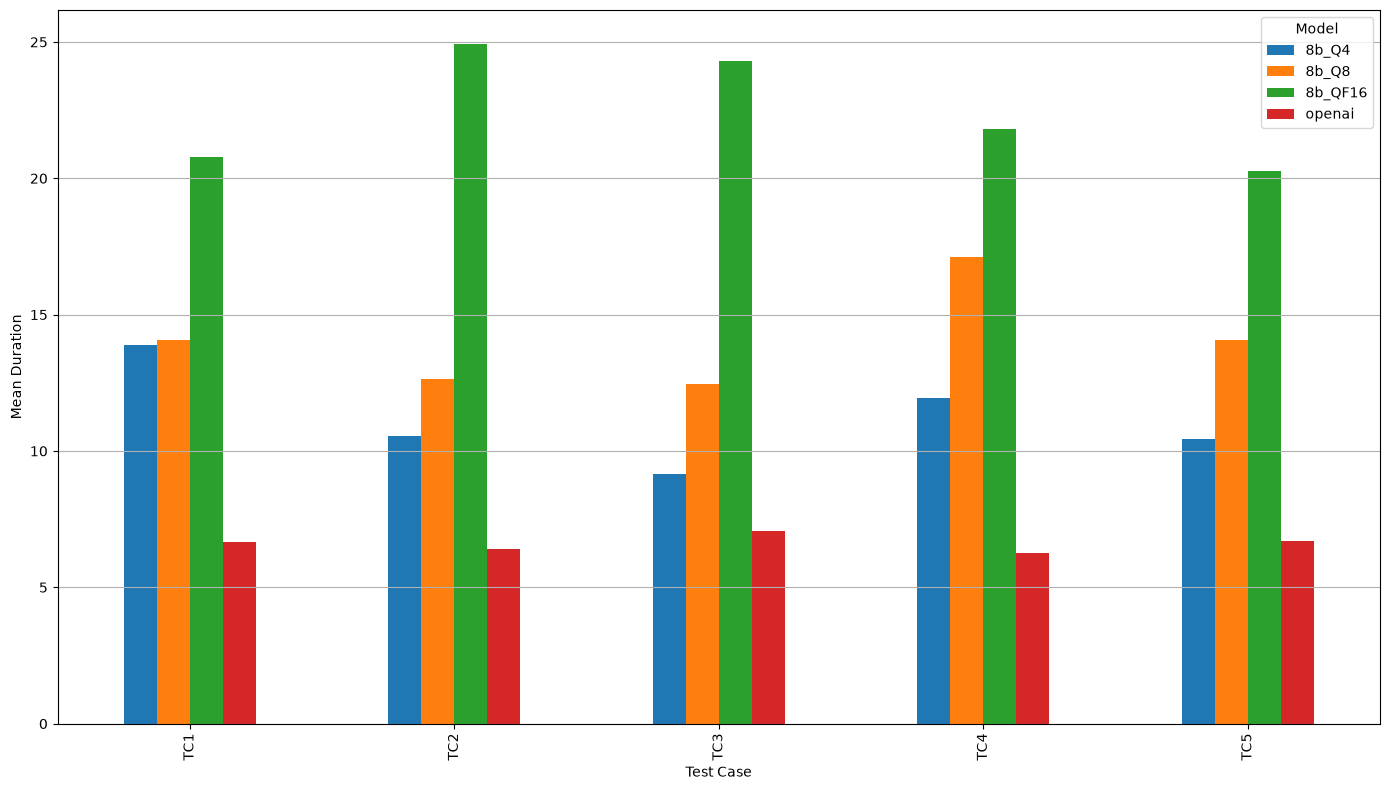

In [19]:
# Plotting bar chart
pivot_df.plot(kind='bar', figsize=(14, 8))
plt.title('')
plt.ylabel('Mean Duration')
plt.xlabel('Test Case')
plt.grid(True, axis='y')
plt.legend(title='Model')
plt.tight_layout()
plt.show()


In [49]:
model_full_data

{'8b_Q4': {'TC3': [{'batch_id': 'TC3',
    'question_id': 1,
    'processing_time': 9.157732938881963,
    'prompt_token_count': 3788,
    'response_token_count': 283,
    'correct': True,
    'answer_relevant': True,
    'context_relevant': True,
    'relevancy_score': 1.0,
    'context_relevancy_score': 1.0,
    'path': ['job_application_tool', 'job_description_tool'],
    'path_len': 2},
   {'batch_id': 'TC3',
    'question_id': 2,
    'processing_time': 13.971043101046234,
    'prompt_token_count': 4411,
    'response_token_count': 438,
    'correct': True,
    'answer_relevant': True,
    'context_relevant': True,
    'relevancy_score': 1.0,
    'context_relevancy_score': 1.0,
    'path': ['job_application_tool', 'job_description_tool'],
    'path_len': 2},
   {'batch_id': 'TC3',
    'question_id': 3,
    'processing_time': 5.3600723329000175,
    'prompt_token_count': 3615,
    'response_token_count': 60,
    'correct': True,
    'answer_relevant': True,
    'context_relevant': T

In [50]:
# Flatten the nested JSON structure
records = []
for model_id, batches in model_full_data.items():
    for batch_id, evaluations in batches.items():
        for record in evaluations:
            record_flat = record.copy()
            record_flat["model_id"] = model_id
            records.append(record_flat)

# Convert to DataFrame
df = pd.DataFrame(records)
df["throughput"] = (df["response_token_count"] + df["response_token_count"]) / df["processing_time"]

# Human evaluation of the case described below asserted tha such rows presented relevant answers to the question in all 15 cases
# update answer relevant records where they are false and the answer is correct -- well, this is not catered for, but kind of implies false positives for the gpt-judge
df.loc[(df['correct'] == True) & (df['answer_relevant'] == False), 'answer_relevant'] = True

# Derived composite metrics
df["hallucination"] = df["answer_relevant"] & (~df["correct"] | ~df["context_relevant"])
df["retrieval_failure"] = (~df["correct"] & ~df["context_relevant"])
df["confident_hallucination"] = df["answer_relevant"] & df["retrieval_failure"]

In [51]:
df.head(20)

,batch_id,question_id,processing_time,prompt_token_count,response_token_count,correct,answer_relevant,context_relevant,relevancy_score,context_relevancy_score,path,path_len,model_id,throughput,hallucination,retrieval_failure,confident_hallucination
0,TC3,1,9.157733,3788,283,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,8b_Q4,61.805690,False,False,False
1,TC3,2,13.971043,4411,438,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,8b_Q4,62.701116,False,False,False
2,TC3,3,5.360072,3615,60,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,8b_Q4,22.387758,False,False,False
3,TC3,4,3.841955,2548,85,False,True,True,1.0,1.0,[job_description_tool],1,8b_Q4,44.248306,True,False,False
4,TC3,5,14.561346,4265,433,False,True,True,1.0,1.0,"[job_description_tool, job_application_tool, j...",3,8b_Q4,59.472523,True,False,False
5,TC3,6,8.195403,2185,297,False,True,True,1.0,1.0,"[job_application_tool, job_post_tool]",2,8b_Q4,72.479653,True,False,False
6,TC3,7,12.309775,4110,457,True,True,True,1.0,1.0,"[job_description_tool, job_application_tool]",2,8b_Q4,74.249935,False,False,False
7,TC3,8,7.640497,1774,351,True,True,True,1.0,1.0,[job_description_tool],1,8b_Q4,91.878845,False,False,False
8,TC3,9,18.701761,3022,832,True,True,True,1.0,1.0,"[job_application_tool, job_post_tool]",2,8b_Q4,88.975577,False,False,False
9,TC3,10,7.334169,2633,228,True,True,True,1.0,1.0,"[job_application_tool, job_post_tool]",2,8b_Q4,62.174729,False,False,False


In [52]:
df.describe()

,question_id,processing_time,prompt_token_count,response_token_count,relevancy_score,context_relevancy_score,path_len,throughput
count,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000,600.000000
mean,15.500000,13.573542,3067.098333,328.205000,0.950000,0.896667,1.706667,55.289160
std,8.662663,14.136848,1074.362722,396.634081,0.218127,0.304648,0.636105,35.836066
min,1.000000,2.487849,672.000000,18.000000,0.000000,0.000000,1.000000,9.053271
25%,8.000000,5.873311,2222.000000,148.000000,1.000000,1.000000,1.000000,26.749381
50%,15.500000,9.343260,3024.000000,253.000000,1.000000,1.000000,2.000000,42.720668
75%,23.000000,16.350376,3816.500000,389.000000,1.000000,1.000000,2.000000,79.154030
max,30.000000,148.146709,8082.000000,6158.000000,1.000000,1.000000,4.000000,171.284454


In [53]:
# Compute summary metrics per model
grouped = df.groupby(["model_id"])

fgcm = grouped.apply(lambda g: pd.Series({
    'failure_given_context_miss': (
        ((~g['context_relevant']) & (~g['correct'])).sum() /
        (~g['context_relevant']).sum()
        if (~g['context_relevant']).sum() > 0 else 0
    ),
    'success_given_context': (
        ((g['context_relevant']) & (g['correct'])).sum() /
        (g['context_relevant']).sum()
        if (g['context_relevant']).sum() > 0 else 0
    ),
    'context_induced_error_rate': (
        ((~g['context_relevant']) & (~g['correct'])).sum() /
        (~g['correct']).sum()
        if (~g['correct']).sum() > 0 else 0
    ),
    'context_sensitivity': (
        g[g['context_relevant']]['correct'].mean() - g[~g['context_relevant']]['correct'].mean()
        if not g[g['context_relevant']]['correct'].empty and not g[~g['context_relevant']]['correct'].empty
        else 0
    )
})).reset_index()

summary1 = grouped.agg({
    "correct": ["mean"],
    "answer_relevant": ["mean"],
    "context_relevant": ["mean"],
    "hallucination": ["mean"],
    "retrieval_failure": ["mean"],
    "confident_hallucination": ["mean"],
    "relevancy_score": ["mean"],
    "context_relevancy_score": ["mean"],
    "processing_time": ["mean"],
    "prompt_token_count": ["mean"],
    "response_token_count": ["mean"],
    "path_len": ["mean"],
    "throughput": ["mean"],
})

# Flatten MultiIndex
summary1.columns = ['_'.join(col).strip() for col in summary1.columns.values]
summary1.reset_index(inplace=True)

summary1 = pd.merge(summary1,fgcm, on=['model_id'])
summary1['failure_rate_mean'] = 1 - summary1['correct_mean']
summary1['context_miss'] = 1 - summary1['context_relevant_mean']


/var/folders/1p/zlvk2j_11h718fq9lpcl0wzm0000gn/T/ipykernel_45100/1733787024.py:4: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fgcm = grouped.apply(lambda g: pd.Series({


In [54]:
summary1.head()

,model_id,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,retrieval_failure_mean,confident_hallucination_mean,relevancy_score_mean,context_relevancy_score_mean,processing_time_mean,prompt_token_count_mean,response_token_count_mean,path_len_mean,throughput_mean,failure_given_context_miss,success_given_context,context_induced_error_rate,context_sensitivity,failure_rate_mean,context_miss
0,8b_Q4,0.460000,0.966667,0.866667,0.520000,0.120000,0.093333,0.966667,0.866667,11.188391,3348.326667,354.426667,1.986667,53.750029,0.900000,0.515385,0.222222,0.415385,0.540000,0.133333
1,8b_Q8,0.506667,0.920000,0.853333,0.426667,0.133333,0.073333,0.920000,0.853333,14.062809,3154.846667,296.606667,1.826667,37.188475,0.909091,0.578125,0.270270,0.487216,0.493333,0.146667
2,8b_QF16,0.493333,0.913333,0.866667,0.420000,0.133333,0.060000,0.913333,0.866667,22.424321,3152.626667,288.073333,1.833333,22.954651,1.000000,0.569231,0.263158,0.569231,0.506667,0.133333
3,openai,0.786667,1.000000,1.000000,0.213333,0.000000,0.000000,1.000000,1.000000,6.618645,2612.593333,373.713333,1.180000,107.263487,0.000000,0.786667,0.000000,0.000000,0.213333,0.000000


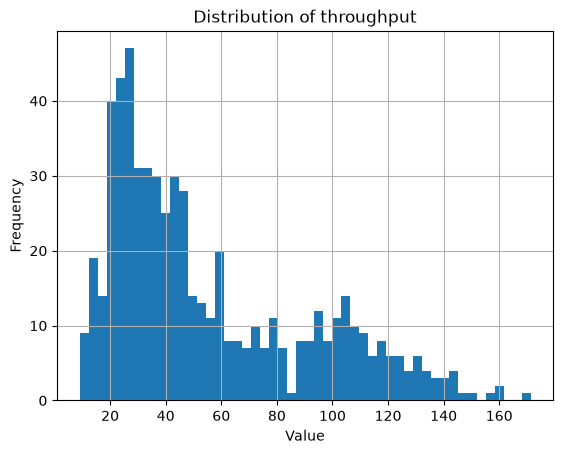

In [25]:
import matplotlib.pyplot as plt

df['throughput'].hist(bins=50)
plt.title('Distribution of throughput')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.show()

In [55]:
from sklearn.preprocessing import MinMaxScaler

range_start = summary1['throughput_mean'].min() / summary1['throughput_mean'].max() * 1
path_range_start = summary1['path_len_mean'].min() / summary1['path_len_mean'].max() * 1
processing_time_range_start = summary1['processing_time_mean'].min() / summary1['processing_time_mean'].max() * 1

throughput_scaler = MinMaxScaler(feature_range=(round(float(range_start), 4), 1))
path_len_scaler = MinMaxScaler(feature_range=(round(float(path_range_start), 4), 1))
processing_time_scaler = MinMaxScaler(feature_range=(round(float(processing_time_range_start), 4), 1))

summary1['throughput_mean_standardized'] = throughput_scaler.fit_transform(
    summary1['throughput_mean'].values.reshape(-1, 1))
summary1['path_len_mean_standardized'] = path_len_scaler.fit_transform(summary1['path_len_mean'].values.reshape(-1, 1))
summary1['processing_time_mean_standardized'] = processing_time_scaler.fit_transform(
    summary1['processing_time_mean'].values.reshape(-1, 1))


In [56]:
summary1.head()

,model_id,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,retrieval_failure_mean,confident_hallucination_mean,relevancy_score_mean,context_relevancy_score_mean,processing_time_mean,...,throughput_mean,failure_given_context_miss,success_given_context,context_induced_error_rate,context_sensitivity,failure_rate_mean,context_miss,throughput_mean_standardized,path_len_mean_standardized,processing_time_mean_standardized
0,8b_Q4,0.460000,0.966667,0.866667,0.520000,0.120000,0.093333,0.966667,0.866667,11.188391,...,53.750029,0.900000,0.515385,0.222222,0.415385,0.540000,0.133333,0.501101,1.000000,0.498972
1,8b_Q8,0.506667,0.920000,0.853333,0.426667,0.133333,0.073333,0.920000,0.853333,14.062809,...,37.188475,0.909091,0.578125,0.270270,0.487216,0.493333,0.146667,0.346700,0.919471,0.627147
2,8b_QF16,0.493333,0.913333,0.866667,0.420000,0.133333,0.060000,0.913333,0.866667,22.424321,...,22.954651,1.000000,0.569231,0.263158,0.569231,0.506667,0.133333,0.214000,0.922826,1.000000
3,openai,0.786667,1.000000,1.000000,0.213333,0.000000,0.000000,1.000000,1.000000,6.618645,...,107.263487,0.000000,0.786667,0.000000,0.000000,0.213333,0.000000,1.000000,0.594000,0.295200


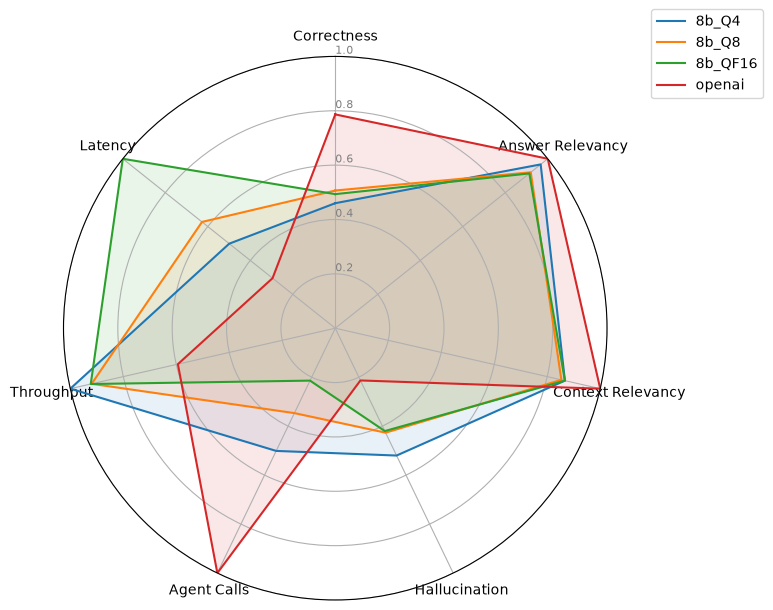

In [57]:
from math import pi

# Prepare data for radar plot
radar_metrics = [
    "correct_mean",
    "answer_relevant_mean",
    "context_relevant_mean",
    "hallucination_mean",
    "throughput_mean_standardized",
    "path_len_mean_standardized",
    "processing_time_mean_standardized",
]

radar_labels = [
    "Correctness",
    "Answer Relevancy",
    "Context Relevancy",
    "Hallucination",
    "Agent Calls",
    "Throughput",
    "Latency"
]

sensitivity_radar_metrics = [
    "failure_given_context_miss",
    "success_given_context",
    "failure_rate_mean",
    "context_induced_error_rate",
    "context_miss",
]

sensitivity_radar_labels = [
    "Context Driven Failure Rate",
    "Context Driven Success Rate",
    "Response Failure Rate",
    "Context Induced Failure Rate",
    "Context Miss",
]

# Function to create radar chart
def create_radar_chart(df, title, metrics, labels):
    num_vars = len(metrics)
    angles = [n / float(num_vars) * 2 * pi for n in range(num_vars)]
    angles += angles[:1]  # Complete the loop

    plt.figure(figsize=(8, 8))
    ax = plt.subplot(111, polar=True)

    for i, row in df.iterrows():
        values = row[metrics].tolist()
        values += values[:1]
        ax.plot(angles, values, label=row['model_id'])
        ax.fill(angles, values, alpha=0.1)

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    plt.xticks(angles[:-1], labels)
    ax.set_rlabel_position(0)
    plt.yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2", "0.4", "0.6", "0.8", "1.0"], color="grey", size=8)
    plt.ylim(0, 1)

    plt.title(title, size=15, color='black', y=1.1)
    plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
    plt.tight_layout()
    plt.show()


# Create the radar chart
create_radar_chart(summary1, "", metrics=radar_metrics, labels=radar_labels)


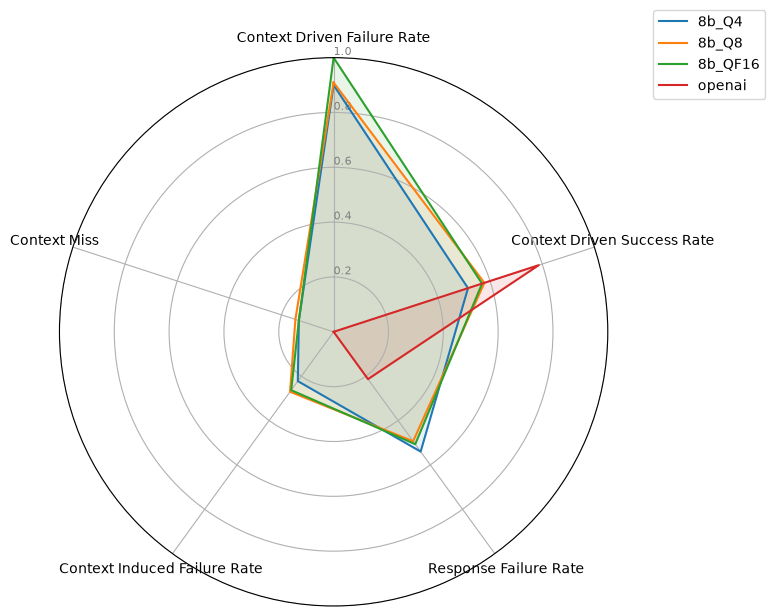

In [58]:
create_radar_chart(summary1, "", metrics=sensitivity_radar_metrics, labels=sensitivity_radar_labels)

In [59]:
# Compute summary metrics per model

# Compute summary metrics per model
summary_grouped = df.groupby(["model_id", "batch_id"])

summary_failure_metrics = summary_grouped.apply(lambda g: pd.Series({
    'context_driven_failure_rate': (
        ((~g['context_relevant']) & (~g['correct'])).sum() /
        (~g['context_relevant']).sum()
        if (~g['context_relevant']).sum() > 0 else 0
    ),
    'context_driven_success_rate': (
        ((g['context_relevant']) & (g['correct'])).sum() /
        (g['context_relevant']).sum()
        if (g['context_relevant']).sum() > 0 else 0
    ),
    'context_induced_error_rate': (
        ((~g['context_relevant']) & (~g['correct'])).sum() /
        (~g['correct']).sum()
        if (~g['correct']).sum() > 0 else 0
    ),
    'context_sensitivity': (
        g[g['context_relevant']]['correct'].mean() - g[~g['context_relevant']]['correct'].mean()
        if not g[g['context_relevant']]['correct'].empty and not g[~g['context_relevant']]['correct'].empty
        else 0
    )
})).reset_index()
summary = summary_grouped.agg({
    "correct": ["mean"],
    "answer_relevant": ["mean"],
    "context_relevant": ["mean"],
    "hallucination": ["mean"],
    "processing_time": ["mean"],
    "prompt_token_count": ["mean"],
    "response_token_count": ["mean"],
    "path_len": ["mean"],
})
summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary.reset_index(inplace=True)

summary = pd.merge(summary_failure_metrics, summary, on=['model_id', 'batch_id'])

/var/folders/1p/zlvk2j_11h718fq9lpcl0wzm0000gn/T/ipykernel_45100/2115210550.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary_failure_metrics = summary_grouped.apply(lambda g: pd.Series({


In [60]:
summary.head(20)

,model_id,batch_id,context_driven_failure_rate,context_driven_success_rate,context_induced_error_rate,context_sensitivity,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,processing_time_mean,prompt_token_count_mean,response_token_count_mean,path_len_mean
0,8b_Q4,TC1,1.000000,0.560000,0.312500,0.560000,0.466667,0.933333,0.833333,0.466667,13.870875,3217.400000,494.533333,1.900000
1,8b_Q4,TC2,1.000000,0.535714,0.133333,0.535714,0.500000,0.966667,0.933333,0.466667,10.536827,3378.666667,266.433333,2.033333
2,8b_Q4,TC3,1.000000,0.629630,0.230769,0.629630,0.566667,1.000000,0.900000,0.433333,9.147888,3162.300000,293.533333,1.900000
3,8b_Q4,TC4,0.800000,0.400000,0.210526,0.200000,0.366667,1.000000,0.833333,0.666667,11.951237,3579.133333,392.000000,2.033333
4,8b_Q4,TC5,0.800000,0.440000,0.222222,0.240000,0.400000,0.933333,0.833333,0.566667,10.435126,3404.133333,325.633333,2.066667
5,8b_Q8,TC1,1.000000,0.583333,0.375000,0.583333,0.466667,0.933333,0.800000,0.466667,14.063842,3125.233333,284.033333,1.866667
6,8b_Q8,TC2,0.714286,0.521739,0.312500,0.236025,0.466667,0.866667,0.766667,0.466667,12.624100,2918.900000,258.933333,1.700000
7,8b_Q8,TC3,1.000000,0.576923,0.266667,0.576923,0.500000,0.933333,0.866667,0.433333,12.454162,2939.933333,267.000000,1.700000
8,8b_Q8,TC4,1.000000,0.576923,0.266667,0.576923,0.500000,0.866667,0.866667,0.366667,17.099105,3431.900000,375.066667,1.933333
9,8b_Q8,TC5,1.000000,0.620690,0.083333,0.620690,0.600000,1.000000,0.966667,0.400000,14.072838,3358.266667,298.000000,1.933333


In [61]:
summary['correct_mean'] = (summary["correct_mean"] * 100).round(2)
summary['answer_relevant_mean'] = (summary["answer_relevant_mean"] * 100).round(2)
summary['context_relevant_mean'] = (summary["context_relevant_mean"] * 100).round(2)
summary['hallucination_mean'] = (summary["hallucination_mean"] * 100).round(2)

In [62]:
# summary.drop(['relevancy_score_mean', 'context_relevancy_score_mean'], axis=1, inplace=True)

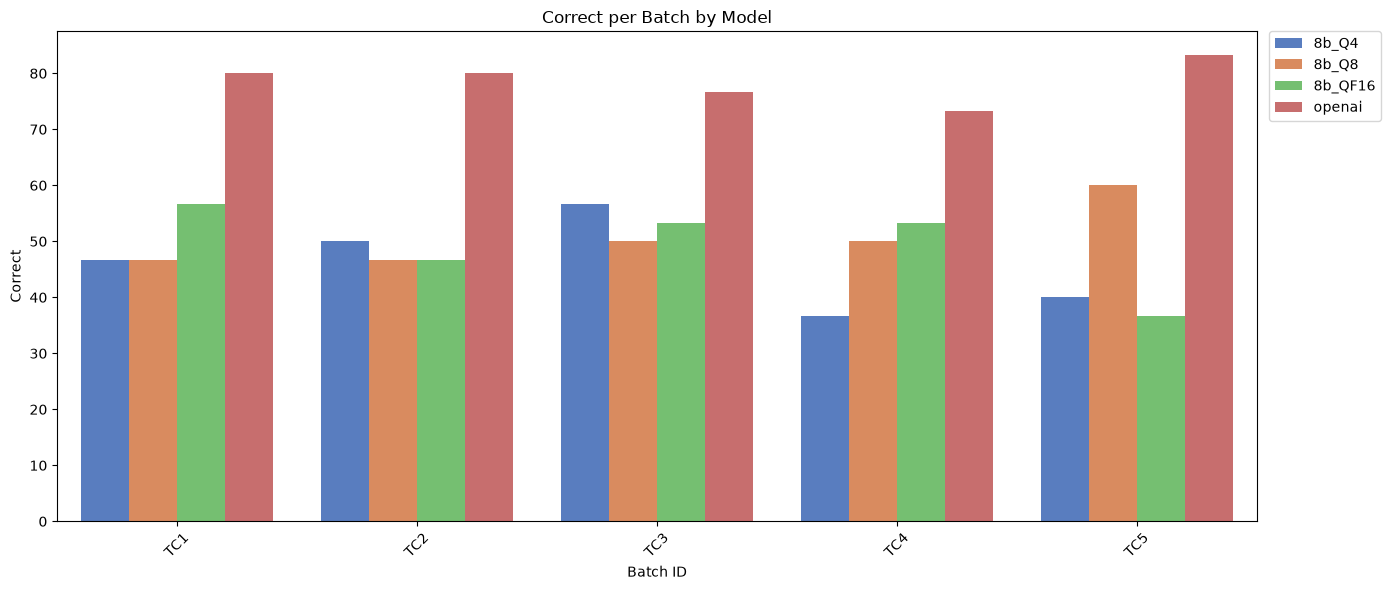

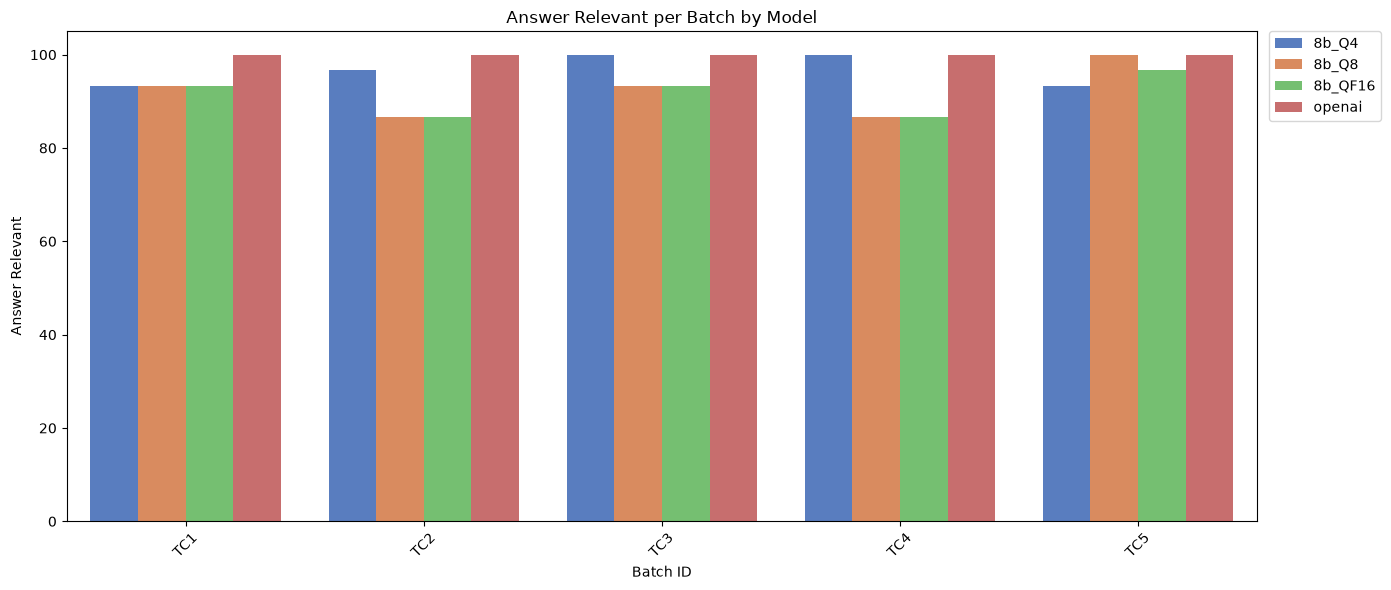

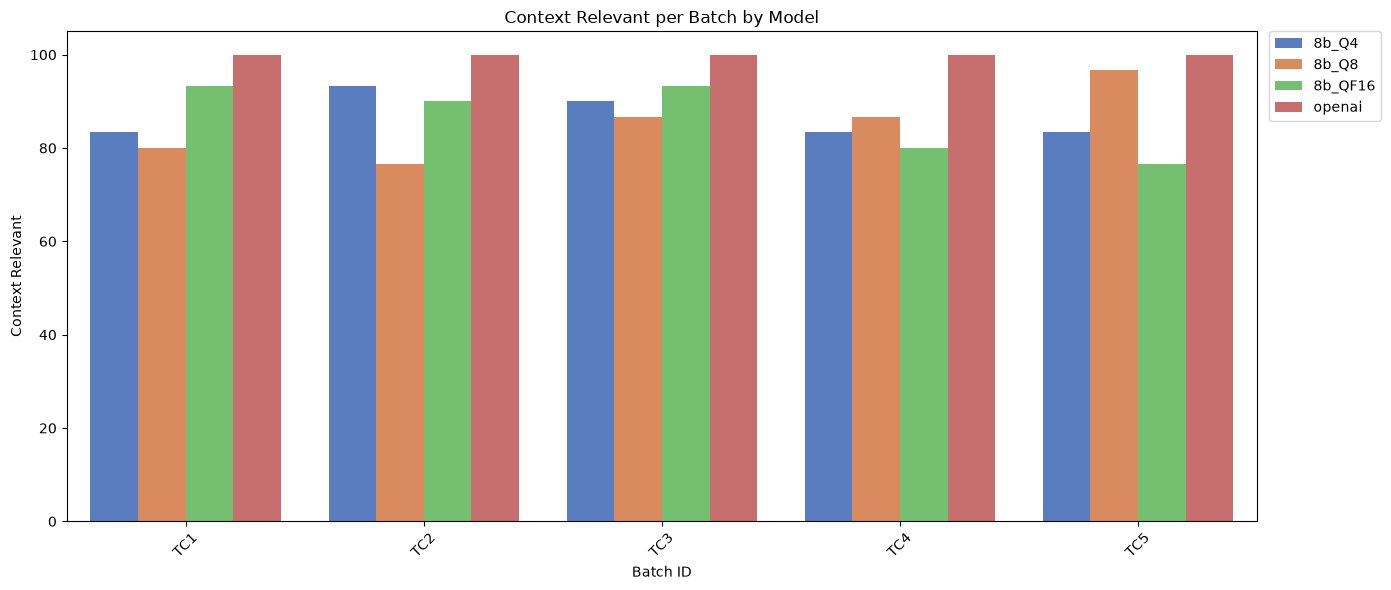

In [63]:
# Define metrics
bar_metrics = ["correct_mean", "answer_relevant_mean", "context_relevant_mean"]
line_metrics = ["path_len_mean"]

# Plot
for bar_metric in bar_metrics:
    plt.figure(figsize=(14, 6))
    ax = sns.barplot(
        x="batch_id", y=bar_metric, hue="model_id", data=summary, palette="muted"
    )

    # # Overlay line plots
    # for line_metric in line_metrics:
    #     for model in summary["model_id"].unique():
    #         subset = summary[summary["model_id"] == model]
    #         ax2 = ax.twinx()
    #         ax2.plot(
    #             subset["batch_id"],
    #             subset[line_metric],
    #             label=f"{model} - {line_metric}",
    #             linestyle="--",
    #             marker="o"
    #         )

    ax.set_title(f"{bar_metric.replace('_mean', '').replace('_', ' ').title()} per Batch by Model")
    ax.set_ylabel(bar_metric.replace('_mean', '').replace('_', ' ').title())
    ax.set_xlabel("Batch ID")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [64]:
# Create bins or group by exact path lengths
path_analysis = df.groupby("path_len").agg({
    "correct": "mean",
    "relevancy_score": "mean",
    "context_relevancy_score": "mean",
    "processing_time": "mean",
    "prompt_token_count": "mean",
    "response_token_count": "mean",
    "throughput": "mean"  # optional, if you've calculated it
}).reset_index()

# Format percentages for readability (optional)
path_analysis["correct_percent"] = (path_analysis["correct"] * 100).round(2)

In [65]:
path_analysis.head()

,path_len,correct,relevancy_score,context_relevancy_score,processing_time,prompt_token_count,response_token_count,throughput,correct_percent
0,1,0.607759,0.913793,0.857759,6.519857,2112.836207,233.435345,73.072916,60.78
1,2,0.523810,0.971429,0.914286,16.622886,3506.501587,348.355556,43.235370,52.38
2,3,0.600000,0.980000,0.960000,26.100387,4479.680000,566.960000,45.282573,60.00
3,4,0.333333,1.000000,1.000000,30.096569,7183.000000,1562.000000,112.436512,33.33


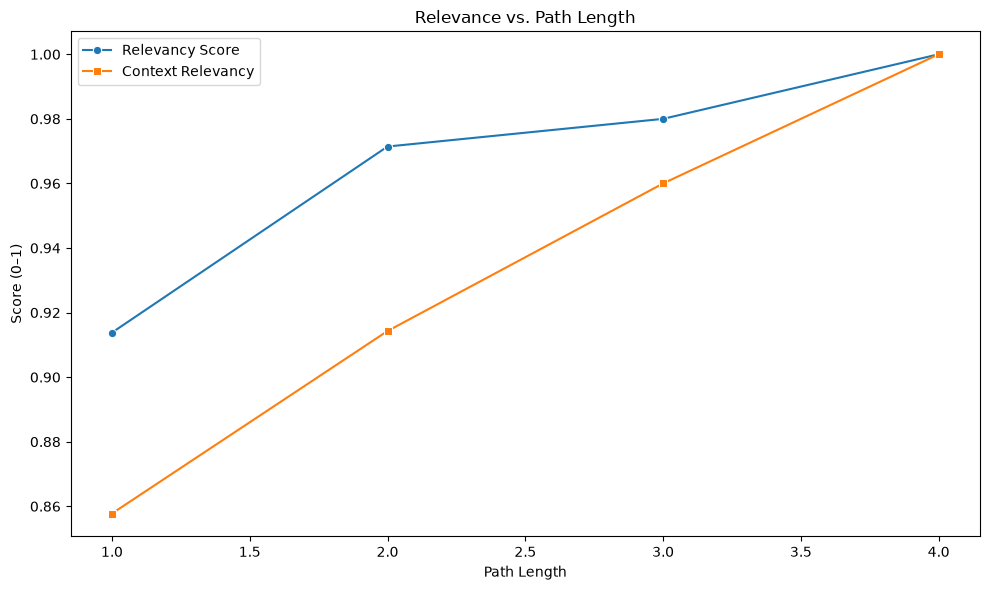

In [66]:
plt.figure(figsize=(10, 6))
sns.lineplot(x="path_len", y="relevancy_score", data=path_analysis, marker="o", label="Relevancy Score")
sns.lineplot(x="path_len", y="context_relevancy_score", data=path_analysis, marker="s", label="Context Relevancy")
plt.title("Relevance vs. Path Length")
plt.ylabel("Score (0–1)")
plt.xlabel("Path Length")
plt.legend()
plt.tight_layout()
plt.show()


In [67]:
summary.head()

,model_id,batch_id,context_driven_failure_rate,context_driven_success_rate,context_induced_error_rate,context_sensitivity,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,processing_time_mean,prompt_token_count_mean,response_token_count_mean,path_len_mean
0,8b_Q4,TC1,1.0,0.560000,0.312500,0.560000,46.67,93.33,83.33,46.67,13.870875,3217.400000,494.533333,1.900000
1,8b_Q4,TC2,1.0,0.535714,0.133333,0.535714,50.00,96.67,93.33,46.67,10.536827,3378.666667,266.433333,2.033333
2,8b_Q4,TC3,1.0,0.629630,0.230769,0.629630,56.67,100.00,90.00,43.33,9.147888,3162.300000,293.533333,1.900000
3,8b_Q4,TC4,0.8,0.400000,0.210526,0.200000,36.67,100.00,83.33,66.67,11.951237,3579.133333,392.000000,2.033333
4,8b_Q4,TC5,0.8,0.440000,0.222222,0.240000,40.00,93.33,83.33,56.67,10.435126,3404.133333,325.633333,2.066667


In [68]:
# ── 1.  START FROM YOUR `summary` DATAFRAME  ──────────────────────────────
# ▸ `summary` must contain one row per (model_id, batch_id) with:
#    - correct_mean
#    - relevancy_score_mean
#    - context_relevancy_score_mean
# If you haven’t built it yet, see the earlier aggregation snippet.

# Convert correctness to % for nicer axes
# summary["correct_mean_percent"] = (summary["correct_mean"] * 100).round(2)
# summary["relevant_mean_percent"] = (summary["answer_relevant_mean"] * 100).round(2)
# summary["context_relevant_mean_percent"] = (summary["context_relevant_mean"] * 100).round(2)


In [69]:
summary.head()

,model_id,batch_id,context_driven_failure_rate,context_driven_success_rate,context_induced_error_rate,context_sensitivity,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,processing_time_mean,prompt_token_count_mean,response_token_count_mean,path_len_mean
0,8b_Q4,TC1,1.0,0.560000,0.312500,0.560000,46.67,93.33,83.33,46.67,13.870875,3217.400000,494.533333,1.900000
1,8b_Q4,TC2,1.0,0.535714,0.133333,0.535714,50.00,96.67,93.33,46.67,10.536827,3378.666667,266.433333,2.033333
2,8b_Q4,TC3,1.0,0.629630,0.230769,0.629630,56.67,100.00,90.00,43.33,9.147888,3162.300000,293.533333,1.900000
3,8b_Q4,TC4,0.8,0.400000,0.210526,0.200000,36.67,100.00,83.33,66.67,11.951237,3579.133333,392.000000,2.033333
4,8b_Q4,TC5,0.8,0.440000,0.222222,0.240000,40.00,93.33,83.33,56.67,10.435126,3404.133333,325.633333,2.066667


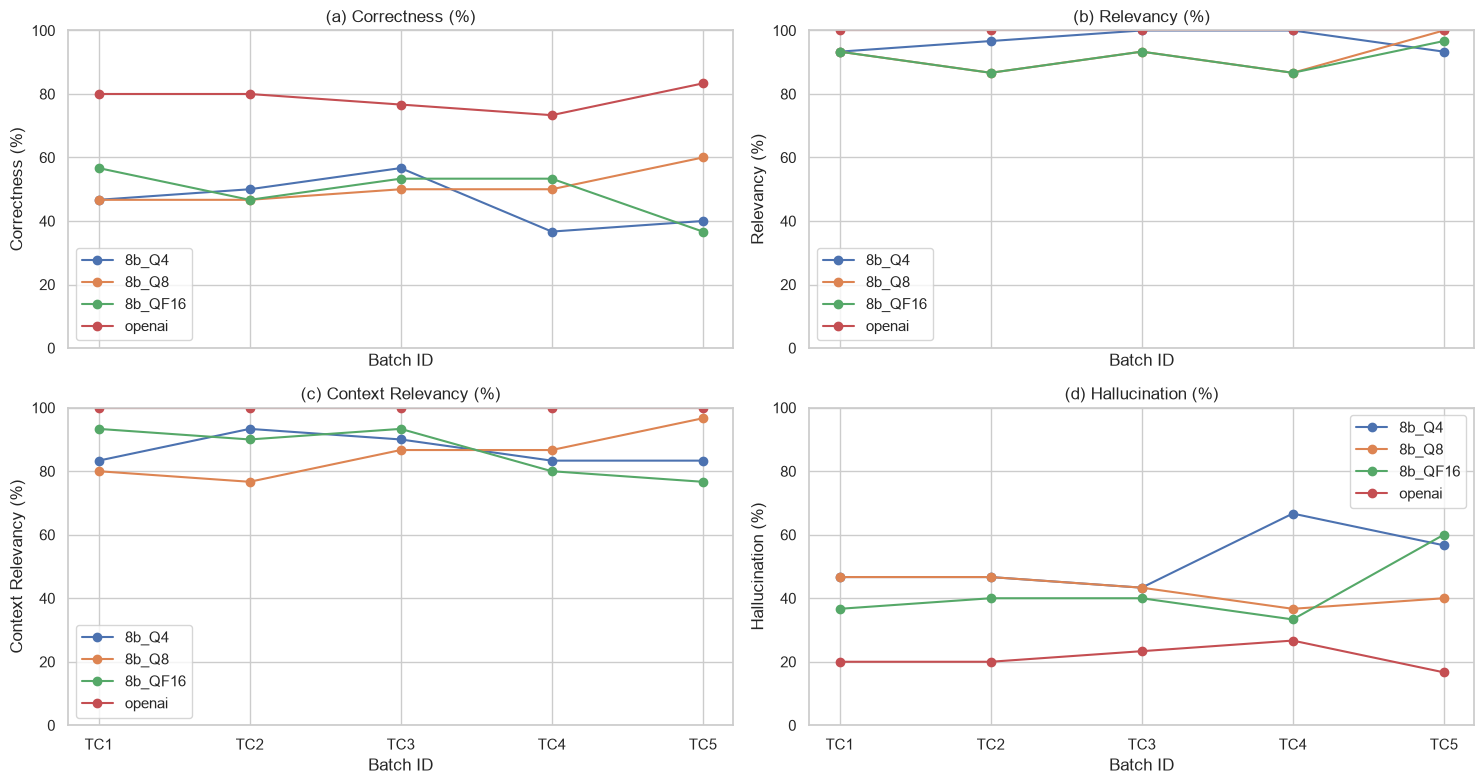

In [70]:
# ── 2.  PLOT SET-UP  ─────────────────────────────────────────────────────
sns.set(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True)
axes_flat = axes.flatten()
letters = ['(a)', '(b)', '(c)', '(d)']  # subplot labels

# Metric mapping:  title → column in `summary`
metrics = {
    "Correctness (%)": "correct_mean",
    "Relevancy (%)": "answer_relevant_mean",
    "Context Relevancy (%)": "context_relevant_mean",
    "Hallucination (%)": "hallucination_mean"
}

# ── 3.  DRAW EACH LINE CHART  ────────────────────────────────────────────
for idx, (title, col) in enumerate(metrics.items()):
    ax = axes_flat[idx]
    for model in summary["model_id"].unique():  # one line per model
        subset = summary[summary["model_id"] == model]
        ax.plot(subset["batch_id"],
                subset[col],
                marker="o",
                label=model)
    ax.set_title(f"{letters[idx]} {title}")
    ax.set_xlabel("Batch ID")
    ax.set_ylabel(title)
    ax.set_ylim(0, 100)
    ax.legend()

# Optional: remove the unused “(d)” subplot
# fig.delaxes(axes_flat[3])

plt.tight_layout()
plt.show()


In [71]:
summary.head()

,model_id,batch_id,context_driven_failure_rate,context_driven_success_rate,context_induced_error_rate,context_sensitivity,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,processing_time_mean,prompt_token_count_mean,response_token_count_mean,path_len_mean
0,8b_Q4,TC1,1.0,0.560000,0.312500,0.560000,46.67,93.33,83.33,46.67,13.870875,3217.400000,494.533333,1.900000
1,8b_Q4,TC2,1.0,0.535714,0.133333,0.535714,50.00,96.67,93.33,46.67,10.536827,3378.666667,266.433333,2.033333
2,8b_Q4,TC3,1.0,0.629630,0.230769,0.629630,56.67,100.00,90.00,43.33,9.147888,3162.300000,293.533333,1.900000
3,8b_Q4,TC4,0.8,0.400000,0.210526,0.200000,36.67,100.00,83.33,66.67,11.951237,3579.133333,392.000000,2.033333
4,8b_Q4,TC5,0.8,0.440000,0.222222,0.240000,40.00,93.33,83.33,56.67,10.435126,3404.133333,325.633333,2.066667


    batch_id  question_id  processing_time  prompt_token_count  \
0        TC3            1         9.157733                3788   
1        TC3            2        13.971043                4411   
2        TC3            3         5.360072                3615   
3        TC3            4         3.841955                2548   
4        TC3            5        14.561346                4265   
..       ...          ...              ...                 ...   
145      TC1           26         5.208604                2174   
146      TC1           27        24.089271                4390   
147      TC1           28         8.459972                3731   
148      TC1           29         7.753923                3338   
149      TC1           30         4.709975                2019   

     response_token_count  correct  answer_relevant  context_relevant  \
0                     283     True             True              True   
1                     438     True             True          

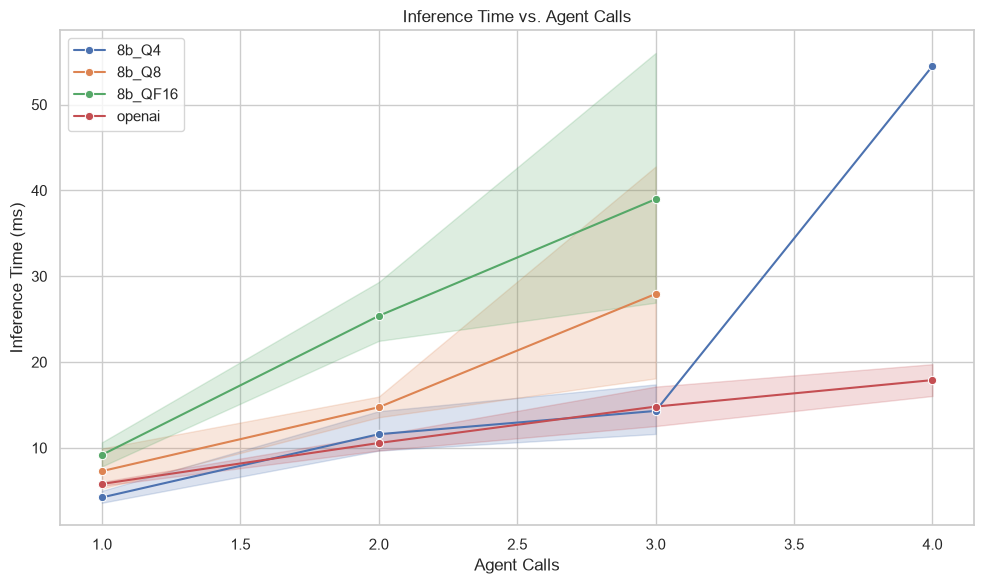

In [72]:

# Plotting
plt.figure(figsize=(10, 6))
for model in df["model_id"].unique():  # one line per model
    subset = df[df["model_id"] == model]
    print(subset)
    sns.lineplot(x="path_len", y="processing_time", data=subset, marker="o", label=model)

    # ax.plot(subset["path_len_mean"],
    #         subset["processing_time_mean"],
    #         marker="o",
    #         label=model)

plt.title('Inference Time vs. Agent Calls')
plt.xlabel('Agent Calls')
plt.ylabel('Inference Time (ms)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [73]:
summary.head()

,model_id,batch_id,context_driven_failure_rate,context_driven_success_rate,context_induced_error_rate,context_sensitivity,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,processing_time_mean,prompt_token_count_mean,response_token_count_mean,path_len_mean
0,8b_Q4,TC1,1.0,0.560000,0.312500,0.560000,46.67,93.33,83.33,46.67,13.870875,3217.400000,494.533333,1.900000
1,8b_Q4,TC2,1.0,0.535714,0.133333,0.535714,50.00,96.67,93.33,46.67,10.536827,3378.666667,266.433333,2.033333
2,8b_Q4,TC3,1.0,0.629630,0.230769,0.629630,56.67,100.00,90.00,43.33,9.147888,3162.300000,293.533333,1.900000
3,8b_Q4,TC4,0.8,0.400000,0.210526,0.200000,36.67,100.00,83.33,66.67,11.951237,3579.133333,392.000000,2.033333
4,8b_Q4,TC5,0.8,0.440000,0.222222,0.240000,40.00,93.33,83.33,56.67,10.435126,3404.133333,325.633333,2.066667


In [74]:
final_summary = summary.groupby("model_id").agg({
    "correct_mean": "mean",
    "answer_relevant_mean": "mean",
    "context_relevant_mean": "mean",
    "hallucination_mean": "mean",
    "context_driven_success_rate": "mean",
    "context_driven_failure_rate": "mean",
    "processing_time_mean": "mean",
    "path_len_mean": "mean",
}).reset_index()

In [75]:
final_summary['context_driven_success_rate'] = (final_summary['context_driven_success_rate'] * 100).round(2)
final_summary['context_driven_failure_rate'] = (final_summary['context_driven_failure_rate'] * 100).round(2)

In [76]:
final_summary.head()

,model_id,correct_mean,answer_relevant_mean,context_relevant_mean,hallucination_mean,context_driven_success_rate,context_driven_failure_rate,processing_time_mean,path_len_mean
0,8b_Q4,46.002,96.666,86.664,52.002,51.31,92.00,11.188391,1.986667
1,8b_Q8,50.668,92.000,85.336,42.668,57.59,94.29,14.062809,1.826667
2,8b_QF16,49.334,91.334,86.666,42.000,56.84,100.00,22.424321,1.833333
3,openai,78.666,100.000,100.000,21.334,78.67,0.00,6.618645,1.180000


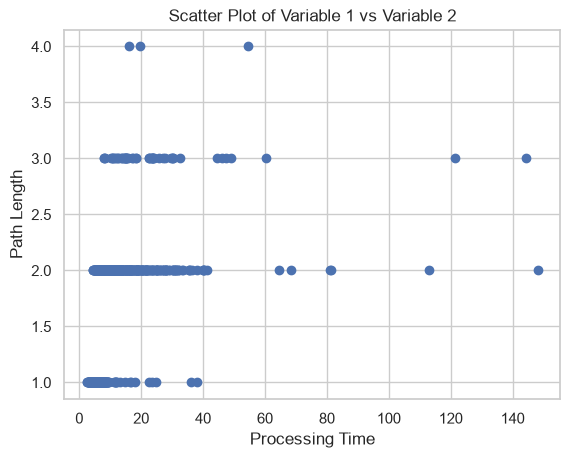

In [77]:

plt.scatter(df['processing_time'], df['path_len'])
plt.xlabel('Processing Time')
plt.ylabel('Path Length')
plt.title('Scatter Plot of Variable 1 vs Variable 2')
plt.show()

In [78]:
# from deepeval.metrics import HallucinationMetric, UnBiasedMetric, NonToxicMetric


In [79]:
filtered_df = df[(df['answer_relevant'] == False) & (df['correct'] == True)]


In [80]:
count = df[(df["answer_relevant"] == True) & (df["correct"] == True)].shape[0]

In [83]:
df[(df["answer_relevant"] == True) & (df["correct"] == True)].shape[0]

337

In [84]:
df[(df["answer_relevant"] == False) & (df["correct"] == True)]

,batch_id,question_id,processing_time,prompt_token_count,response_token_count,correct,answer_relevant,context_relevant,relevancy_score,context_relevancy_score,path,path_len,model_id,throughput,hallucination,retrieval_failure,confident_hallucination


In [85]:
df.head()

,batch_id,question_id,processing_time,prompt_token_count,response_token_count,correct,answer_relevant,context_relevant,relevancy_score,context_relevancy_score,path,path_len,model_id,throughput,hallucination,retrieval_failure,confident_hallucination
0,TC3,1,9.157733,3788,283,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,8b_Q4,61.805690,False,False,False
1,TC3,2,13.971043,4411,438,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,8b_Q4,62.701116,False,False,False
2,TC3,3,5.360072,3615,60,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,8b_Q4,22.387758,False,False,False
3,TC3,4,3.841955,2548,85,False,True,True,1.0,1.0,[job_description_tool],1,8b_Q4,44.248306,True,False,False
4,TC3,5,14.561346,4265,433,False,True,True,1.0,1.0,"[job_description_tool, job_application_tool, j...",3,8b_Q4,59.472523,True,False,False


In [86]:
grouped = df.groupby(['model_id', 'batch_id'])

In [87]:
grouped.head()

,batch_id,question_id,processing_time,prompt_token_count,response_token_count,correct,answer_relevant,context_relevant,relevancy_score,context_relevancy_score,path,path_len,model_id,throughput,hallucination,retrieval_failure,confident_hallucination
0,TC3,1,9.157733,3788,283,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,8b_Q4,61.805690,False,False,False
1,TC3,2,13.971043,4411,438,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,8b_Q4,62.701116,False,False,False
2,TC3,3,5.360072,3615,60,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,8b_Q4,22.387758,False,False,False
3,TC3,4,3.841955,2548,85,False,True,True,1.0,1.0,[job_description_tool],1,8b_Q4,44.248306,True,False,False
4,TC3,5,14.561346,4265,433,False,True,True,1.0,1.0,"[job_description_tool, job_application_tool, j...",3,8b_Q4,59.472523,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
570,TC1,1,12.071255,2688,662,True,True,True,1.0,1.0,[job_application_tool],1,openai,109.682054,False,False,False
571,TC1,2,5.336896,2148,133,True,True,True,1.0,1.0,[job_application_tool],1,openai,49.841707,False,False,False
572,TC1,3,3.349962,2068,63,True,True,True,1.0,1.0,[job_application_tool],1,openai,37.612368,False,False,False
573,TC1,4,8.029115,3582,255,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,openai,63.518829,False,False,False


In [88]:
mean_metrics = grouped[['correct', 'answer_relevant', 'context_relevant']].mean().reset_index()

In [89]:
mean_metrics

,model_id,batch_id,correct,answer_relevant,context_relevant
0,8b_Q4,TC1,0.466667,0.933333,0.833333
1,8b_Q4,TC2,0.500000,0.966667,0.933333
2,8b_Q4,TC3,0.566667,1.000000,0.900000
3,8b_Q4,TC4,0.366667,1.000000,0.833333
4,8b_Q4,TC5,0.400000,0.933333,0.833333
5,8b_Q8,TC1,0.466667,0.933333,0.800000
6,8b_Q8,TC2,0.466667,0.866667,0.766667
7,8b_Q8,TC3,0.500000,0.933333,0.866667
8,8b_Q8,TC4,0.500000,0.866667,0.866667
9,8b_Q8,TC5,0.600000,1.000000,0.966667


In [257]:
grouped

In [90]:
fgcm = grouped.apply(
    lambda g: (
            ((~g['context_relevant']) & (~g['correct'])).sum() /
            (~g['context_relevant']).sum()
    ) if (~g['context_relevant']).sum() > 0 else 0,
).reset_index(name='failure_given_context_miss')


/var/folders/1p/zlvk2j_11h718fq9lpcl0wzm0000gn/T/ipykernel_45100/2420938499.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  fgcm = grouped.apply(


In [91]:
fgcm

,model_id,batch_id,failure_given_context_miss
0,8b_Q4,TC1,1.000000
1,8b_Q4,TC2,1.000000
2,8b_Q4,TC3,1.000000
3,8b_Q4,TC4,0.800000
4,8b_Q4,TC5,0.800000
5,8b_Q8,TC1,1.000000
6,8b_Q8,TC2,0.714286
7,8b_Q8,TC3,1.000000
8,8b_Q8,TC4,1.000000
9,8b_Q8,TC5,1.000000


In [93]:
aggregated_results = pd.merge(mean_metrics, fgcm, on=['model_id', 'batch_id'])

In [94]:
aggregated_results

,model_id,batch_id,correct,answer_relevant,context_relevant,failure_given_context_miss
0,8b_Q4,TC1,0.466667,0.933333,0.833333,1.000000
1,8b_Q4,TC2,0.500000,0.966667,0.933333,1.000000
2,8b_Q4,TC3,0.566667,1.000000,0.900000,1.000000
3,8b_Q4,TC4,0.366667,1.000000,0.833333,0.800000
4,8b_Q4,TC5,0.400000,0.933333,0.833333,0.800000
5,8b_Q8,TC1,0.466667,0.933333,0.800000,1.000000
6,8b_Q8,TC2,0.466667,0.866667,0.766667,0.714286
7,8b_Q8,TC3,0.500000,0.933333,0.866667,1.000000
8,8b_Q8,TC4,0.500000,0.866667,0.866667,1.000000
9,8b_Q8,TC5,0.600000,1.000000,0.966667,1.000000


In [95]:
df.loc[(df['correct'] == True) & (df['answer_relevant'] == False), 'answer_relevant'] = True

In [96]:
df.head()


,batch_id,question_id,processing_time,prompt_token_count,response_token_count,correct,answer_relevant,context_relevant,relevancy_score,context_relevancy_score,path,path_len,model_id,throughput,hallucination,retrieval_failure,confident_hallucination
0,TC3,1,9.157733,3788,283,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,8b_Q4,61.805690,False,False,False
1,TC3,2,13.971043,4411,438,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,8b_Q4,62.701116,False,False,False
2,TC3,3,5.360072,3615,60,True,True,True,1.0,1.0,"[job_application_tool, job_description_tool]",2,8b_Q4,22.387758,False,False,False
3,TC3,4,3.841955,2548,85,False,True,True,1.0,1.0,[job_description_tool],1,8b_Q4,44.248306,True,False,False
4,TC3,5,14.561346,4265,433,False,True,True,1.0,1.0,"[job_description_tool, job_application_tool, j...",3,8b_Q4,59.472523,True,False,False
